# Bank Customer Churn & Retention Analytics — Data Cleaning
### Data Analyst Project (10,000 bank customers, churn + satisfaction data)

**Goal:** Clean a bank customer export, handle PII responsibly, and
engineer features for churn/retention analysis


## Setup
Setting the environment and importing key libraries.

In [ ]:
import pandas as pd
import numpy as np
import hashlib

pd.set_option('display.max_columns', 50)


## 1. Load the raw data
We read our target CSV file into a DataFrame and inspect its initial shape and data quality basics.

In [ ]:
RAW_PATH = "bank_churn.csv"
df = pd.read_csv(RAW_PATH)
print("Raw shape:", df.shape)
print(df.isnull().sum().sum(), "total missing values")
print(df.duplicated().sum(), "exact duplicate rows")
df.head()


Raw shape: (10000, 18)
0 total missing values
0 exact duplicate rows


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 2. Handle PII responsibly

Customer surnames represent personally identifiable information (PII). We replace them with a one-way SHA-256 hash to protect privacy while preserving unique identifier properties.

In [ ]:
df["surname_hash"] = df["Surname"].apply(
    lambda s: hashlib.sha256(str(s).encode()).hexdigest()[:10]
)
df = df.drop(columns=["Surname", "RowNumber"])
df[["surname_hash"]].head()


,surname_hash
0,fdcd57e82f
1,21f5358c1f
2,b839933c7b
3,cb1edc7273
4,483d4bce16


## 3. Rename columns and fix data types
We standardize column names into clean, snake_case formatting and cast binary integer flags to proper boolean types.

In [ ]:
df = df.rename(columns={
    "CustomerId": "customer_id",
    "CreditScore": "credit_score",
    "Geography": "country",
    "Gender": "gender",
    "Age": "age",
    "Tenure": "tenure_years",
    "Balance": "balance",
    "NumOfProducts": "num_products",
    "HasCrCard": "has_credit_card",
    "IsActiveMember": "is_active_member",
    "EstimatedSalary": "estimated_salary",
    "Exited": "churned",
    "Complain": "complained",
    "Satisfaction Score": "satisfaction_score",
    "Card Type": "card_type",
    "Point Earned": "points_earned",
})

bool_cols = ["has_credit_card", "is_active_member", "churned", "complained"]
for col in bool_cols:
    df[col] = df[col].astype(bool)

df["card_type"] = df["card_type"].str.title()
df.dtypes


,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure_years,int64
balance,float64
num_products,int64
has_credit_card,bool
is_active_member,bool


## 4. A real data-quality finding: possible target leakage

Before feature engineering, we inspect relationships between columns to identify data quality anomalies - detecting potential target leakage between customer complaints and churn outcomes.

In [ ]:
mismatch = (df["complained"] != df["churned"]).sum()
print(f"complained vs. churned mismatch: {mismatch} rows out of {len(df)} "
      f"({mismatch/len(df):.2%})")

pd.crosstab(df["churned"], df["complained"])


complained vs. churned mismatch: 14 rows out of 10000 (0.14%)


complained,False,True
churned,,
False,7952,10
True,4,2034


Only 14 out of 10,000 rows disagree. In a real project, this is a red
flag for target leakage — complained may have been recorded
because the customer churned (e.g. an exit-interview complaint), rather
than being an independent early-warning signal. We keep the column for
descriptive analysis (it's still a real, interesting fact about these
customers) but flag clearly that it should **not** be used as a predictor
in any churn-prediction model without further investigation.

## 5. Feature engineering

We construct categorical bands (credit score, age, balance, and tenure) along with a customer engagement score to facilitate cohort analysis in downstream tools.

In [ ]:
credit_bins = [300, 579, 669, 739, 799, 851]
credit_labels = ["Poor", "Fair", "Good", "Very Good", "Exceptional"]
df["credit_score_band"] = pd.cut(df["credit_score"], bins=credit_bins,
                                   labels=credit_labels, right=False)

age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
df["age_band"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

df["balance_tier"] = np.select(
    [df["balance"] == 0, df["balance"] < 100_000],
    ["Zero Balance", "Under 100k"],
    default="100k+",
)

df["tenure_band"] = np.select(
    [df["tenure_years"] <= 2, df["tenure_years"] <= 5, df["tenure_years"] <= 8],
    ["0-2 yrs", "3-5 yrs", "6-8 yrs"],
    default="9-10 yrs",
)

df["engagement_score"] = (
    df["has_credit_card"].astype(int)
    + df["is_active_member"].astype(int)
    + (df["num_products"] >= 2).astype(int)
)

df[["credit_score_band", "age_band", "balance_tier", "tenure_band", "engagement_score"]].head()


,credit_score_band,age_band,balance_tier,tenure_band,engagement_score
0,Fair,36-45,Zero Balance,0-2 yrs,2
1,Fair,36-45,Under 100k,0-2 yrs,1
2,Poor,36-45,100k+,6-8 yrs,2
3,Good,36-45,Zero Balance,0-2 yrs,1
4,Exceptional,36-45,100k+,0-2 yrs,2


## 6. Build a `credit_score_bands` reference table
We create a clean dimensional lookup table for credit score tiers, mirroring standard banking data warehouse schemas.

In [ ]:
credit_score_bands = pd.DataFrame({
    "band": credit_labels,
    "min_score": credit_bins[:-1],
    "max_score": [b - 1 for b in credit_bins[1:]],
    "description": [
        "High credit risk, limited product eligibility",
        "Below-average risk profile",
        "Acceptable, mainstream risk profile",
        "Low risk, eligible for premium products",
        "Lowest risk, top-tier customer",
    ],
})
credit_score_bands


,band,min_score,max_score,description
0,Poor,300,578,"High credit risk, limited product eligibility"
1,Fair,579,668,Below-average risk profile
2,Good,669,738,"Acceptable, mainstream risk profile"
3,Very Good,739,798,"Low risk, eligible for premium products"
4,Exceptional,799,850,"Lowest risk, top-tier customer"


## 7. Sanity checks
Validation checks to ensure customer IDs remain unique, numerical attributes fall within expected ranges, and clean data boundaries are preserved.

In [ ]:
assert df["customer_id"].is_unique
assert df["credit_score"].between(300, 850).all()
assert df["age"].between(18, 100).all()
assert df["churned"].isin([True, False]).all()
print("All checks passed.")


All checks passed.


## 8. Quick exploratory peek
A quick look into overall churn patterns across key demographic segments like country and age bracket.

<Axes: title={'center': 'Churn Rate by Country'}, xlabel='country'>

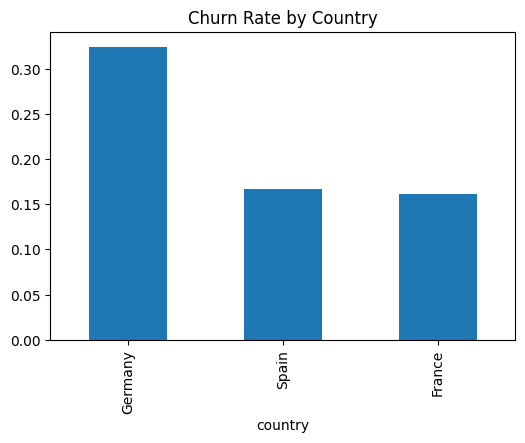

In [ ]:
df.groupby("country")["churned"].mean().sort_values(ascending=False).plot(
    kind="bar", title="Churn Rate by Country", figsize=(6,4))


/tmp/ipykernel_521/3086384037.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_band")["churned"].mean().plot(


<Axes: title={'center': 'Churn Rate by Age Band'}, xlabel='age_band'>

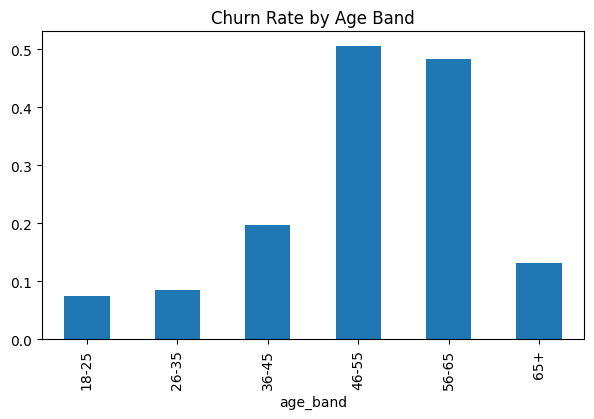

In [ ]:
df.groupby("age_band")["churned"].mean().plot(
    kind="bar", title="Churn Rate by Age Band", figsize=(7,4))


## 9. Export the clean tables

In [ ]:
df.to_csv("customers_clean.csv", index=False)
credit_score_bands.to_csv("credit_score_bands.csv", index=False)


Saved 2 processed files
